# Task 2 (Entrega Final)

## Integrantes

- Sergio Orellana 221122
- Rodrigo Mansilla 22611
- Ricardo Chuy 221007


## Contexto y entorno de validacion

En la Task 1 se establecio que el sistema real de deteccion de intrusiones tiene un estado de 256 dimensiones continuas, cuatro acciones discretas y eventos criticos extremadamente raros (menos del 0.1 por ciento de los pasos). Escalar directamente a ese entorno complicaria la validacion de las propiedades algoritmicas de DQN, Double DQN y PER, ya que no se contaria con una forma sencilla de verificar si el agente aprende correctamente.

Por esa razon se utiliza `LunarLander-v2` de Gymnasium como entorno proxy. Comparte las dos propiedades estructurales relevantes del problema real: estado continuo de alta dimension (8 variables: posicion, velocidad, angulo, velocidad angular y contacto de las patas con el suelo) y espacio de acciones discreto con 4 opciones (no hacer nada, motor izquierdo, motor principal, motor derecho). La recompensa de LunarLander tambien es dispersa en el sentido de que el aterrizaje exitoso u otros eventos importantes ocurren solo en ciertos pasos, lo cual permite observar de forma controlada como el buffer de replay y el calculo de targets se comportan antes de aplicar esas mismas ideas al dominio de ciberseguridad.

Nota de compatibilidad: el enunciado especifica `LunarLander-v2`, pero esa version fue removida de Gymnasium (las versiones actuales de la libreria solo registran `LunarLander-v3`, con exactamente la misma fisica, las mismas 8 dimensiones de estado y las mismas 4 acciones, ver `gymnasium.error.DeprecatedEnv`). Por eso la implementacion usa `LunarLander-v3` en el codigo, sin que esto cambie ninguna de las propiedades algoritmicas que se estan validando.


In [1]:
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
from collections import deque
import matplotlib.pyplot as plt

torch.set_num_threads(1)
device = torch.device("cpu")

# Hiperparametros fijados por el enunciado de la Task 2.1
HIDDEN = 128
BUFFER_CAPACITY = 50_000
BATCH_SIZE = 64
TARGET_UPDATE_EVERY = 500        # pasos de entorno, no episodios
EPS_START, EPS_END, EPS_DECAY_STEPS = 1.0, 0.05, 10_000
GAMMA = 0.99
LR = 1e-3
N_EVAL_STATES = 100


## Arquitectura de la red Q(s,a;w)

Como se argumento en la Task 1.1a, el estado no es una imagen sino un vector numerico, por lo que no se utiliza una red convolucional. Se implementa una red totalmente conectada (MLP) con dos capas ocultas de 128 neuronas y activacion ReLU, que recibe el vector de estado y produce en una sola pasada el valor estimado de las cuatro acciones:

$$
Q(s,\cdot;\mathbf{w}): \mathbb{R}^{8} \;\; \text{Dense(128) + ReLU} \;\; \text{Dense(128) + ReLU} \;\; \text{Dense(4)}
$$


In [2]:
class QNetwork(nn.Module):
    """
    Aproximador Q(s,a;w) para estado vectorial (no imagen).
    Dos capas ocultas de 128 neuronas con ReLU, salida de tamanio action_dim.
    """
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


## Experience Replay uniforme

El buffer circular guarda hasta 50000 transiciones $(s,a,r,s',d)$ y cada minibatch de tamanio 64 se obtiene con muestreo uniforme, es decir $P(i) = 1/N$ para cualquier transicion $i$ almacenada. Este mecanismo rompe la correlacion temporal entre transiciones consecutivas de un mismo episodio, que es el requisito de muestras aproximadamente independientes que necesita el descenso de gradiente estocastico.


In [3]:
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s2, d):
        self.buffer.append((s, a, r, s2, d))

    def sample(self, batch_size):
        import random
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        return s, a, r, s2, d, None, None  # weights=None, idx=None para compatibilidad con PER

    def __len__(self):
        return len(self.buffer)


## Prioritized Experience Replay (PER)

Tal como se planteo en la Task 1.1c, con eventos criticos que ocurren con probabilidad aproximada $p=0.001$, un minibatch de 64 transiciones con muestreo uniforme tiene una probabilidad cercana a 0.062 de contener al menos un evento critico, por lo que casi todos los minibatches entrenarian unicamente con trafico normal. PER corrige esto asignando una probabilidad de muestreo proporcional al error temporal (TD error) de cada transicion:

$$
p_i = (|\delta_i| + \epsilon_p)^{\alpha}, \qquad P(i) = \frac{p_i}{\sum_k p_k}
$$

Como el muestreo deja de ser uniforme, se introduce un sesgo en la actualizacion, el cual se corrige con pesos de importancia que se normalizan por el maximo del minibatch:

$$
w_i = \left(\frac{1}{N \, P(i)}\right)^{\beta}
$$

En la implementacion, $\alpha=0.6$ se mantiene fijo y $\beta$ crece linealmente de 0.4 a 1.0 durante el entrenamiento, siguiendo lo solicitado en el enunciado.


In [4]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity=50000, alpha=0.6, eps=1e-5):
        self.capacity = capacity
        self.alpha = alpha
        self.eps = eps
        self.buffer = []
        self.priorities = np.zeros((capacity,), dtype=np.float64)
        self.pos = 0

    def push(self, s, a, r, s2, d):
        # nuevas transiciones entran con la prioridad maxima observada hasta el momento,
        # asi se garantiza que se muestreen al menos una vez antes de recalcular su TD error
        max_prio = self.priorities.max() if self.buffer else 1.0
        if len(self.buffer) < self.capacity:
            self.buffer.append((s, a, r, s2, d))
        else:
            self.buffer[self.pos] = (s, a, r, s2, d)
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        # P(i) = p_i / sum_k p_k, con p_i = (|delta_i| + eps)^alpha
        N = len(self.buffer)
        prios = self.priorities[:N]
        probs = prios ** self.alpha
        probs /= probs.sum()

        idx = np.random.choice(N, batch_size, p=probs)
        batch = [self.buffer[i] for i in idx]
        s, a, r, s2, d = map(np.array, zip(*batch))

        # w_i = (1/(N*P(i)))^beta, normalizado por max(w) del minibatch para estabilidad numerica
        weights = (N * probs[idx]) ** (-beta)
        weights /= weights.max()
        return s, a, r, s2, d, weights.astype(np.float32), idx

    def update_priorities(self, idx, td_errors):
        # se guarda la prioridad cruda |delta|+eps; el exponente alpha se aplica en sample()
        for i, err in zip(idx, td_errors):
            self.priorities[i] = abs(err) + self.eps

    def __len__(self):
        return len(self.buffer)


## Politica epsilon-greedy y calculo del target (DQN vs Double DQN)

El unico cambio de implementacion entre DQN y Double DQN, tal como se discutio en la Task 1.2b, esta en como se calcula el target:

$$
y_t^{DQN} = r_t + \gamma (1-d_t) \max_{a'} Q(s_{t+1}, a'; \mathbf{w}^{-})
$$

$$
a^{*} = \arg\max_{a'} Q(s_{t+1}, a'; \mathbf{w}), \qquad y_t^{DDQN} = r_t + \gamma (1-d_t) Q(s_{t+1}, a^{*}; \mathbf{w}^{-})
$$

En DQN estandar, la misma red target $\mathbf{w}^{-}$ selecciona y evalua la mejor accion siguiente, lo cual introduce el sesgo de sobreestimacion descrito en la Task 1.2a. En Double DQN, la red online $\mathbf{w}$ selecciona la accion y la red target $\mathbf{w}^{-}$ unicamente la evalua, desacoplando ambos pasos.


In [5]:
def epsilon_by_step(step):
    frac = min(1.0, step / EPS_DECAY_STEPS)
    return EPS_START + frac * (EPS_END - EPS_START)


def select_action(qnet, state, eps, action_dim):
    if np.random.rand() < eps:
        return np.random.randint(action_dim)
    with torch.no_grad():
        s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        q = qnet(s)
        return int(torch.argmax(q, dim=1).item())


def compute_targets(qnet, target_net, s2, r, d, double_dqn):
    """
    double_dqn=False: target de DQN estandar (max sobre la red target).
    double_dqn=True: target de Double DQN (seleccion con la red online,
                      evaluacion con la red target).
    """
    with torch.no_grad():
        if double_dqn:
            next_actions = torch.argmax(qnet(s2), dim=1, keepdim=True)
            next_q = target_net(s2).gather(1, next_actions).squeeze(1)
        else:
            next_q = target_net(s2).max(dim=1).values
        y = r + GAMMA * (1.0 - d) * next_q
    return y


## Ciclo de entrenamiento

Por episodio se registran tres cantidades, que son las necesarias para detectar sobreestimacion segun el enunciado:

1. Recompensa total del episodio.
2. Valor Q promedio estimado sobre un conjunto fijo de 100 estados de evaluacion (no se usan para entrenar, solo para medir como cambia la estimacion de valor a lo largo del entrenamiento).
3. Target promedio usado durante las actualizaciones de ese episodio.

El conjunto de 100 estados de evaluacion se genera una sola vez al inicio, con una politica aleatoria independiente del entrenamiento, de forma que los tres algoritmos (DQN, Double DQN y Double DQN con PER) se evaluan siempre sobre los mismos estados y las comparaciones son validas.


In [6]:
def train_agent(algo="dqn", n_episodes=400, per=False, seed=0, log_path=None):
    """
    algo: "dqn" o "double_dqn"
    per:  si es True, usa PrioritizedReplayBuffer (pensado para combinarse con double_dqn)
    """
    double_dqn = (algo == "double_dqn")

    env = gym.make("LunarLander-v3")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    np.random.seed(seed)
    torch.manual_seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)

    qnet = QNetwork(state_dim, action_dim, HIDDEN).to(device)
    target_net = QNetwork(state_dim, action_dim, HIDDEN).to(device)
    target_net.load_state_dict(qnet.state_dict())
    target_net.eval()

    optimizer = optim.Adam(qnet.parameters(), lr=LR)

    if per:
        buffer = PrioritizedReplayBuffer(BUFFER_CAPACITY, alpha=0.6)
    else:
        buffer = ReplayBuffer(BUFFER_CAPACITY)

    # conjunto fijo de 100 estados de evaluacion, generado con una politica aleatoria independiente
    eval_states = []
    a_space = env.action_space
    tmp_env = gym.make("LunarLander-v3")
    s0, _ = tmp_env.reset(seed=seed + 999)
    eval_states.append(s0)
    while len(eval_states) < N_EVAL_STATES:
        a = a_space.sample()
        s2, r, term, trunc, _ = tmp_env.step(a)
        eval_states.append(s2)
        if term or trunc:
            tmp_env.reset()
    tmp_env.close()
    eval_states = torch.as_tensor(np.array(eval_states), dtype=torch.float32, device=device)

    global_step = 0
    history = {"episode_reward": [], "avg_q": [], "avg_target": []}

    t0 = time.time()
    for ep in range(n_episodes):
        s, _ = env.reset()
        ep_reward = 0.0
        done = False
        ep_targets = []

        while not done:
            eps = epsilon_by_step(global_step)
            a = select_action(qnet, s, eps, action_dim)
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            buffer.push(s, a, r, s2, float(term))
            s = s2
            ep_reward += r
            global_step += 1

            if len(buffer) >= BATCH_SIZE:
                if per:
                    beta = min(1.0, 0.4 + (global_step / (n_episodes * 300)) * 0.6)
                    bs, ba, br, bs2, bd, w, idx = buffer.sample(BATCH_SIZE, beta=beta)
                else:
                    bs, ba, br, bs2, bd, w, idx = buffer.sample(BATCH_SIZE)

                bs = torch.as_tensor(bs, dtype=torch.float32, device=device)
                ba = torch.as_tensor(ba, dtype=torch.int64, device=device).unsqueeze(1)
                br = torch.as_tensor(br, dtype=torch.float32, device=device)
                bs2 = torch.as_tensor(bs2, dtype=torch.float32, device=device)
                bd = torch.as_tensor(bd, dtype=torch.float32, device=device)

                y = compute_targets(qnet, target_net, bs2, br, bd, double_dqn)
                q_sa = qnet(bs).gather(1, ba).squeeze(1)
                td_error = (q_sa.detach() - y).numpy()

                if per and w is not None:
                    w_t = torch.as_tensor(w, dtype=torch.float32, device=device)
                    loss = (w_t * (q_sa - y) ** 2).mean()
                else:
                    loss = nn.functional.smooth_l1_loss(q_sa, y)

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(qnet.parameters(), 10.0)
                optimizer.step()

                if per and idx is not None:
                    buffer.update_priorities(idx, td_error)

                ep_targets.append(y.mean().item())

                if global_step % TARGET_UPDATE_EVERY == 0:
                    target_net.load_state_dict(qnet.state_dict())

        with torch.no_grad():
            avg_q_eval = qnet(eval_states).max(dim=1).values.mean().item()

        history["episode_reward"].append(ep_reward)
        history["avg_q"].append(avg_q_eval)
        history["avg_target"].append(float(np.mean(ep_targets)) if ep_targets else 0.0)

        if (ep + 1) % 25 == 0:
            recent = np.mean(history["episode_reward"][-25:])
            elapsed = time.time() - t0
            print(f"[{algo}{'+PER' if per else ''}] ep {ep+1}/{n_episodes} "
                  f"reward(mean25)={recent:.1f} avgQ={avg_q_eval:.2f} eps={eps:.3f} t={elapsed:.1f}s")
            if log_path:
                with open(log_path, "w") as f:
                    json.dump(history, f)

    env.close()
    if log_path:
        with open(log_path, "w") as f:
            json.dump(history, f)
    return history


## Ejecucion de los experimentos

Cada entrenamiento de 400 episodios toma entre 5 y 10 minutos en CPU. Las siguientes celdas estan listas para ejecutarse; se recomienda correrlas una por una y verificar que la carpeta `results` exista antes de guardar los archivos.


In [7]:
import os
os.makedirs("results", exist_ok=True)

history_dqn = train_agent(algo="dqn", n_episodes=400, seed=0, log_path="results/dqn.json")


C:\Users\Ricardo Chuy\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


[dqn] ep 25/400 reward(mean25)=-148.8 avgQ=6.77 eps=0.740 t=9.0s


[dqn] ep 50/400 reward(mean25)=-66.2 avgQ=22.08 eps=0.094 t=32.5s


[dqn] ep 75/400 reward(mean25)=13.8 avgQ=60.11 eps=0.050 t=114.6s


[dqn] ep 100/400 reward(mean25)=105.8 avgQ=75.85 eps=0.050 t=191.3s


...

[dqn] ep 300/400 reward(mean25)=161.9 avgQ=91.21 eps=0.050 t=618.1s


[dqn] ep 325/400 reward(mean25)=136.2 avgQ=90.62 eps=0.050 t=649.5s


[dqn] ep 350/400 reward(mean25)=107.3 avgQ=88.50 eps=0.050 t=676.3s


[dqn] ep 375/400 reward(mean25)=33.2 avgQ=87.37 eps=0.050 t=697.7s


[dqn] ep 400/400 reward(mean25)=164.5 avgQ=85.72 eps=0.050 t=730.4s


In [8]:
history_ddqn = train_agent(algo="double_dqn", n_episodes=400, seed=0, log_path="results/double_dqn.json")


[double_dqn] ep 25/400 reward(mean25)=-149.1 avgQ=6.82 eps=0.756 t=8.0s


[double_dqn] ep 50/400 reward(mean25)=-72.6 avgQ=20.73 eps=0.200 t=28.5s


[double_dqn] ep 75/400 reward(mean25)=-17.4 avgQ=57.09 eps=0.050 t=106.9s


[double_dqn] ep 100/400 reward(mean25)=-43.1 avgQ=69.94 eps=0.050 t=190.0s


[double_dqn] ep 125/400 reward(mean25)=79.5 avgQ=72.06 eps=0.050 t=279.2s


...

[double_dqn] ep 300/400 reward(mean25)=-40.3 avgQ=72.13 eps=0.050 t=460.8s


[double_dqn] ep 325/400 reward(mean25)=-59.3 avgQ=72.86 eps=0.050 t=470.7s


[double_dqn] ep 350/400 reward(mean25)=-61.6 avgQ=74.93 eps=0.050 t=483.9s


[double_dqn] ep 375/400 reward(mean25)=-2.0 avgQ=73.17 eps=0.050 t=496.5s


[double_dqn] ep 400/400 reward(mean25)=-59.7 avgQ=70.33 eps=0.050 t=513.3s


In [9]:
history_ddqn_per = train_agent(algo="double_dqn", per=True, n_episodes=400, seed=0,
                                log_path="results/double_dqn_per.json")


[double_dqn+PER] ep 25/400 reward(mean25)=-169.0 avgQ=5.00 eps=0.766 t=7.7s


[double_dqn+PER] ep 50/400 reward(mean25)=-130.2 avgQ=13.83 eps=0.445 t=19.5s


[double_dqn+PER] ep 75/400 reward(mean25)=-69.0 avgQ=32.99 eps=0.050 t=54.3s


[double_dqn+PER] ep 100/400 reward(mean25)=-75.6 avgQ=41.14 eps=0.050 t=78.1s


[double_dqn+PER] ep 125/400 reward(mean25)=-30.4 avgQ=46.89 eps=0.050 t=105.4s


...

[double_dqn+PER] ep 300/400 reward(mean25)=-33.7 avgQ=70.48 eps=0.050 t=296.5s


[double_dqn+PER] ep 325/400 reward(mean25)=38.0 avgQ=78.83 eps=0.050 t=380.7s


[double_dqn+PER] ep 350/400 reward(mean25)=-11.8 avgQ=102.79 eps=0.050 t=473.8s


[double_dqn+PER] ep 375/400 reward(mean25)=-5.1 avgQ=117.49 eps=0.050 t=559.6s


[double_dqn+PER] ep 400/400 reward(mean25)=-47.5 avgQ=114.36 eps=0.050 t=629.3s


# Task 2.2


In [10]:
def load_history(path):
    with open(path) as f:
        return json.load(f)


def moving_average(values, window=20):
    values = np.array(values, dtype=float)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


### a. Recompensa promedio por episodio, DQN vs Double DQN


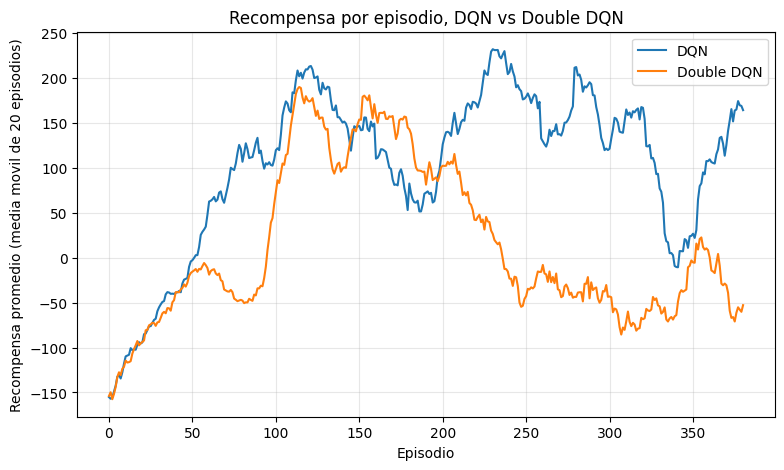

In [11]:
h_dqn = load_history("results/dqn.json")
h_ddqn = load_history("results/double_dqn.json")

ma_dqn = moving_average(h_dqn["episode_reward"], 20)
ma_ddqn = moving_average(h_ddqn["episode_reward"], 20)

plt.figure(figsize=(9, 5))
plt.plot(ma_dqn, label="DQN")
plt.plot(ma_ddqn, label="Double DQN")
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio (media movil de 20 episodios)")
plt.title("Recompensa por episodio, DQN vs Double DQN")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("results/reward_dqn_vs_ddqn.png", dpi=150, bbox_inches="tight")
plt.show()


En la ejecucion final de 400 episodios con semilla 0, ambos algoritmos parten de recompensas negativas (los primeros episodios corresponden a una politica casi aleatoria) con medias muy similares en el primer bloque (DQN -107.5, Double DQN -110.8 en los episodios 0 a 50). A partir de ahi las dos curvas se separan: DQN sube y se mantiene en un rango alto durante el resto del entrenamiento (entre 100 y 175 de recompensa promedio por bloque de 50 episodios desde el episodio 100 en adelante), mientras que Double DQN alcanza un pico en los episodios 100 a 200 (116 y 143) pero despues se deteriora de forma sostenida hasta terminar en valores negativos (-60.4 y -30.8 en los ultimos dos bloques).

Usando el criterio de una media movil de 20 episodios sostenida por al menos 10 episodios consecutivos, DQN cruza a valores positivos primero (episodio 52) que Double DQN (episodio 95), y DQN es tambien el unico que llega a sostener recompensas por encima de 200 (desde el episodio 225); Double DQN no alcanza ese umbral en ningun tramo de los 400 episodios. En esta ejecucion, entonces, DQN converge mas rapido y termina con mayor recompensa que Double DQN.

Este resultado no coincide con lo esperado teoricamente, donde se anticipaba que Double DQN igualara o superara a DQN al evitar perseguir acciones con valor sobreestimado. La explicacion no esta en que la reduccion del sesgo de sobreestimacion no haya ocurrido (la parte b muestra que si ocurrio, y de forma clara), sino en que reducir ese sesgo no garantiza por si solo una mejor politica en una sola ejecucion con una sola semilla: el entrenamiento de ambos algoritmos sigue siendo inestable (la curva de Double DQN muestra un patron de subida y colapso posterior, no una convergencia monotona), y esa inestabilidad puede deberse a la propia politica epsilon-greedy, a la actualizacion periodica de la red target, o simplemente a la variabilidad de una sola semilla. Se necesitarian varias semillas para separar una ventaja sistematica de Double DQN de la variabilidad propia del entrenamiento en este entorno.


### b. Valor Q promedio estimado durante el entrenamiento


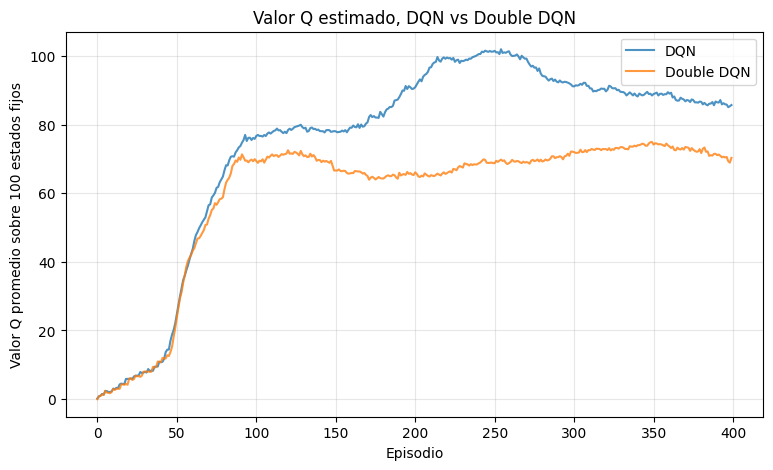

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(h_dqn["avg_q"], label="DQN", alpha=0.8)
plt.plot(h_ddqn["avg_q"], label="Double DQN", alpha=0.8)
plt.xlabel("Episodio")
plt.ylabel("Valor Q promedio sobre 100 estados fijos")
plt.title("Valor Q estimado, DQN vs Double DQN")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("results/avgq_dqn_vs_ddqn.png", dpi=150, bbox_inches="tight")
plt.show()


En la ejecucion final, el valor Q promedio de DQN termina en aproximadamente 85.7 en el ultimo episodio (86.2 de media en los ultimos 25), mientras que el de Double DQN termina en aproximadamente 70.3 (71.4 de media en los ultimos 25), sobre el mismo conjunto de 100 estados fijos. El patron es consistente y claro: DQN es mayor que Double DQN en el 96 por ciento de los episodios, con una media global de 74.9 frente a 60.0 (una diferencia relativa cercana al 20 por ciento).

Este resultado si coincide con lo esperado teoricamente: Double DQN estima sistematicamente valores Q mas bajos que DQN sobre los mismos estados, consistente con la reduccion del sesgo de sobreestimacion que introduce al desacoplar la seleccion de la accion de su evaluacion. Vale la pena notar la aparente contradiccion con la parte a: aunque el sesgo de sobreestimacion se redujo exactamente como predice la teoria, eso no se tradujo en una mejor recompensa final en esta ejecucion. Esto muestra que la propiedad que Double DQN garantiza es sobre la estimacion de valor, no directamente sobre el desempenio de la politica resultante en cada corrida individual.


### c. Double DQN con muestreo uniforme vs Double DQN con PER

Esta comparacion usa los resultados de Double DQN con muestreo uniforme (`results/double_dqn.json`) y Double DQN con Prioritized Experience Replay (`results/double_dqn_per.json`), ambos entrenados 400 episodios con la misma semilla y los mismos hiperparametros salvo el mecanismo de muestreo del buffer.


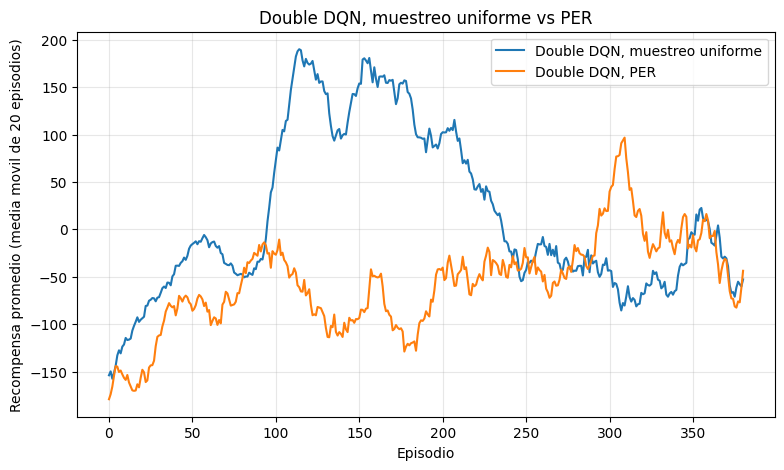

In [13]:
h_ddqn_per = load_history("results/double_dqn_per.json")
ma_ddqn_per = moving_average(h_ddqn_per["episode_reward"], 20)

plt.figure(figsize=(9, 5))
plt.plot(ma_ddqn, label="Double DQN, muestreo uniforme")
plt.plot(ma_ddqn_per, label="Double DQN, PER")
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio (media movil de 20 episodios)")
plt.title("Double DQN, muestreo uniforme vs PER")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("results/reward_ddqn_vs_per.png", dpi=150, bbox_inches="tight")
plt.show()


En esta ejecucion, Double DQN con muestreo uniforme converge a valores positivos sostenidos antes (episodio 95, con el mismo criterio de media movil de 20 episodios sostenida 10 episodios) que Double DQN con PER (episodio 293), justo lo contrario de lo que anticipa la teoria de que PER deberia acelerar la convergencia temprana al reforzar el uso de las transiciones con mayor error temporal.

Mirando la evolucion por bloques de 50 episodios, el muestreo uniforme alcanza su mejor tramo entre los episodios 100 y 250 (recompensa promedio de 116, 143 y 63), pero luego se degrada de forma marcada en la segunda mitad del entrenamiento, terminando en valores negativos (-60.4 y -30.8 en los ultimos dos bloques). PER nunca alcanza ese pico intermedio, se mantiene negativo durante casi todo el entrenamiento, pero tampoco sufre una caida tan pronunciada al final, y en el bloque de los episodios 300 a 350 termina claramente por encima del muestreo uniforme (13.1 frente a -60.4).

La diferencia mas visible en esta ejecucion, entonces, no esta en una convergencia temprana mas rapida de PER (que no se observo), sino en una mayor resistencia al deterioro tardio que si afecta a Double DQN con muestreo uniforme. Una posible razon de que PER no muestre la ventaja temprana esperada es que las transiciones nuevas entran al buffer con la prioridad maxima observada hasta ese momento (ver el comentario en `PrioritizedReplayBuffer.push`), asi que al inicio del entrenamiento casi todas las transiciones compiten con prioridades similares y el muestreo se parece bastante al uniforme; el efecto de priorizar por error temporal real solo se vuelve marcado mas adelante, cuando ya hay suficientes transiciones con prioridades recalculadas para diferenciarse. Con una sola semilla no se puede descartar tampoco que parte de esta diferencia sea variabilidad del entrenamiento y no un efecto sistematico de PER; se necesitarian varias semillas para confirmarlo con mas seguridad.


### d. Relevancia de PER en el dominio real de deteccion de intrusiones

El resultado empirico de la parte c en LunarLander fue mixto: PER no acelero la convergencia temprana como se esperaba, y solo mostro una ventaja clara hacia el final del entrenamiento, cuando evito el deterioro marcado que si sufrio el muestreo uniforme. A primera vista esto podria sugerir que PER aporta poco en este entorno, pero es consistente con la explicacion de la Task 1.1c: en LunarLander los aterrizajes exitosos y los choques, que son las transiciones con error temporal alto, no son raros, ocurren en una fraccion importante de los episodios desde el principio. El muestreo uniforme ya las ve con frecuencia razonable, asi que priorizarlas aporta relativamente poco frente a la variabilidad propia del entrenamiento.

En el sistema de deteccion de intrusiones, el calculo realizado en la Task 1.1c mostro que un minibatch uniforme de 64 transiciones tiene una probabilidad cercana a 0.062 de incluir al menos un evento critico, lo que implica que el 93.8 por ciento de los minibatches entrenarian unicamente con trafico normal. Ese es exactamente el escenario donde la ventaja de PER deberia ser mucho mas marcada que la observada aqui, no menos: mientras en LunarLander el muestreo uniforme ya alcanza las transiciones informativas por su cuenta, en el dominio real casi nunca lo haria, y PER seria practicamente el unico mecanismo que garantiza que las pocas transiciones de intrusiones reales se usen con la frecuencia suficiente para que la red aprenda a distinguirlas del trafico normal. El resultado moderado de esta ejecucion en LunarLander no debilita ese argumento, lo respalda: la ventaja de PER crece precisamente en la medida en que los eventos importantes se vuelven mas raros, y en el dominio real son mucho mas raros que en este entorno proxy.


# Task 2.3

Investigacion bibliografica y dictamen tecnico. Pendiente de completar.
